# 🌳 Weather-Based Picnic Prediction using Decision Tree

## Project Overview

Weather plays an important role in planning outdoor activities.

Many travel agencies and event organizers need to decide whether an outdoor picnic should be conducted or postponed depending on weather conditions.

In this project, we will build a Decision Tree Classification model that predicts whether a picnic should be conducted based on weather conditions.

The project demonstrates a complete Machine Learning workflow including:

- Data Generation
- Exploratory Data Analysis
- Data Cleaning
- Feature Engineering
- Decision Tree Theory
- Entropy
- Information Gain
- Gini Index
- Model Training
- Model Evaluation
- Tree Visualization
- Feature Importance
- Hyperparameter Tuning
- Model Saving
- Predicting New Weather Conditions

# Business Problem

A travel company organizes outdoor picnics every weekend.

Sometimes weather changes unexpectedly.

If heavy rainfall or high humidity occurs, the company loses money because customers cancel at the last minute.

The goal is to predict whether the picnic should be conducted using weather information.

Target Variable

Picnic

Yes → Conduct Picnic

No → Cancel Picnic

# Why Decision Tree?

Decision Tree is one of the most interpretable Machine Learning algorithms.

Instead of learning mathematical equations,
it learns a series of IF-ELSE rules.

Example

IF Rainfall > 5 mm

        Cancel Picnic

ELSE

IF Humidity < 70%

        Conduct Picnic

ELSE

        Cancel Picnic

This makes Decision Trees easy to understand and explain.

In [2]:
# ============================================================
# Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (

    confusion_matrix,

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    classification_report,

    roc_curve,

    roc_auc_score

)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Dataset

Instead of downloading a dataset,
we will create a realistic weather dataset.

Features

Temperature (°C)

Humidity (%)

Windy

Rainfall (mm)

Cloud Cover

Target

Picnic

Yes

No

In [3]:
# ============================================================
# Create Synthetic Dataset
# ============================================================

np.random.seed(42)

n = 1500

temperature = np.random.randint(18,42,n)

humidity = np.random.randint(30,100,n)

windy = np.random.randint(0,2,n)

rainfall = np.random.randint(0,21,n)

cloud_cover = np.random.randint(0,3,n)

In [4]:
# ============================================================
# Create Picnic Decision
# ============================================================

picnic = []

for t,h,w,r,c in zip(

    temperature,

    humidity,

    windy,

    rainfall,

    cloud_cover

):

    if (

        r < 4

        and

        h < 70

        and

        w == 0

        and

        c == 0

    ):

        picnic.append(1)

    else:

        picnic.append(0)

In [5]:
df = pd.DataFrame({

    "Temperature":temperature,

    "Humidity":humidity,

    "Windy":windy,

    "Rainfall":rainfall,

    "CloudCover":cloud_cover,

    "Picnic":picnic

})

df.head()

,Temperature,Humidity,Windy,Rainfall,CloudCover,Picnic
0,24,77,0,6,0,0
1,37,88,0,16,2,0
2,32,68,0,20,1,0
3,28,47,1,14,1,0
4,25,88,0,19,2,0


In [6]:
df.shape

(1500, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Temperature  1500 non-null   int32
 1   Humidity     1500 non-null   int32
 2   Windy        1500 non-null   int32
 3   Rainfall     1500 non-null   int32
 4   CloudCover   1500 non-null   int32
 5   Picnic       1500 non-null   int64
dtypes: int32(5), int64(1)
memory usage: 41.1 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,1500.0,29.400667,7.120061,18.0,23.0,29.0,36.00,41.0
Humidity,1500.0,63.800000,20.162416,30.0,46.0,64.0,80.25,99.0
Windy,1500.0,0.483333,0.499889,0.0,0.0,0.0,1.00,1.0
Rainfall,1500.0,10.314000,5.908074,0.0,5.0,11.0,15.00,20.0
CloudCover,1500.0,0.998000,0.806492,0.0,0.0,1.0,2.00,2.0
Picnic,1500.0,0.016000,0.125517,0.0,0.0,0.0,0.00,1.0


In [9]:
df["Picnic"].value_counts()

Picnic
0    1476
1      24
Name: count, dtype: int64

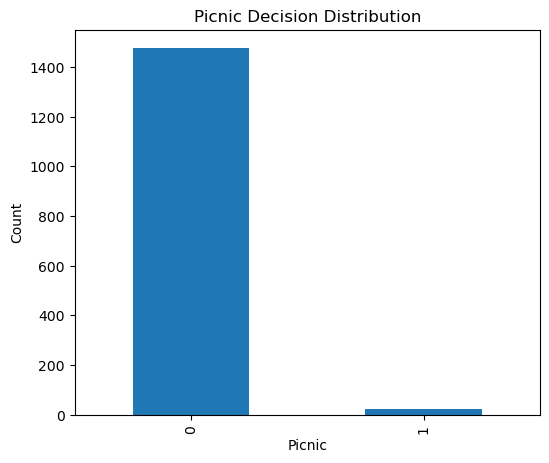

In [10]:
plt.figure(figsize=(6,5))

df["Picnic"].value_counts().plot(

    kind="bar"

)

plt.title("Picnic Decision Distribution")

plt.xlabel("Picnic")

plt.ylabel("Count")

plt.show()

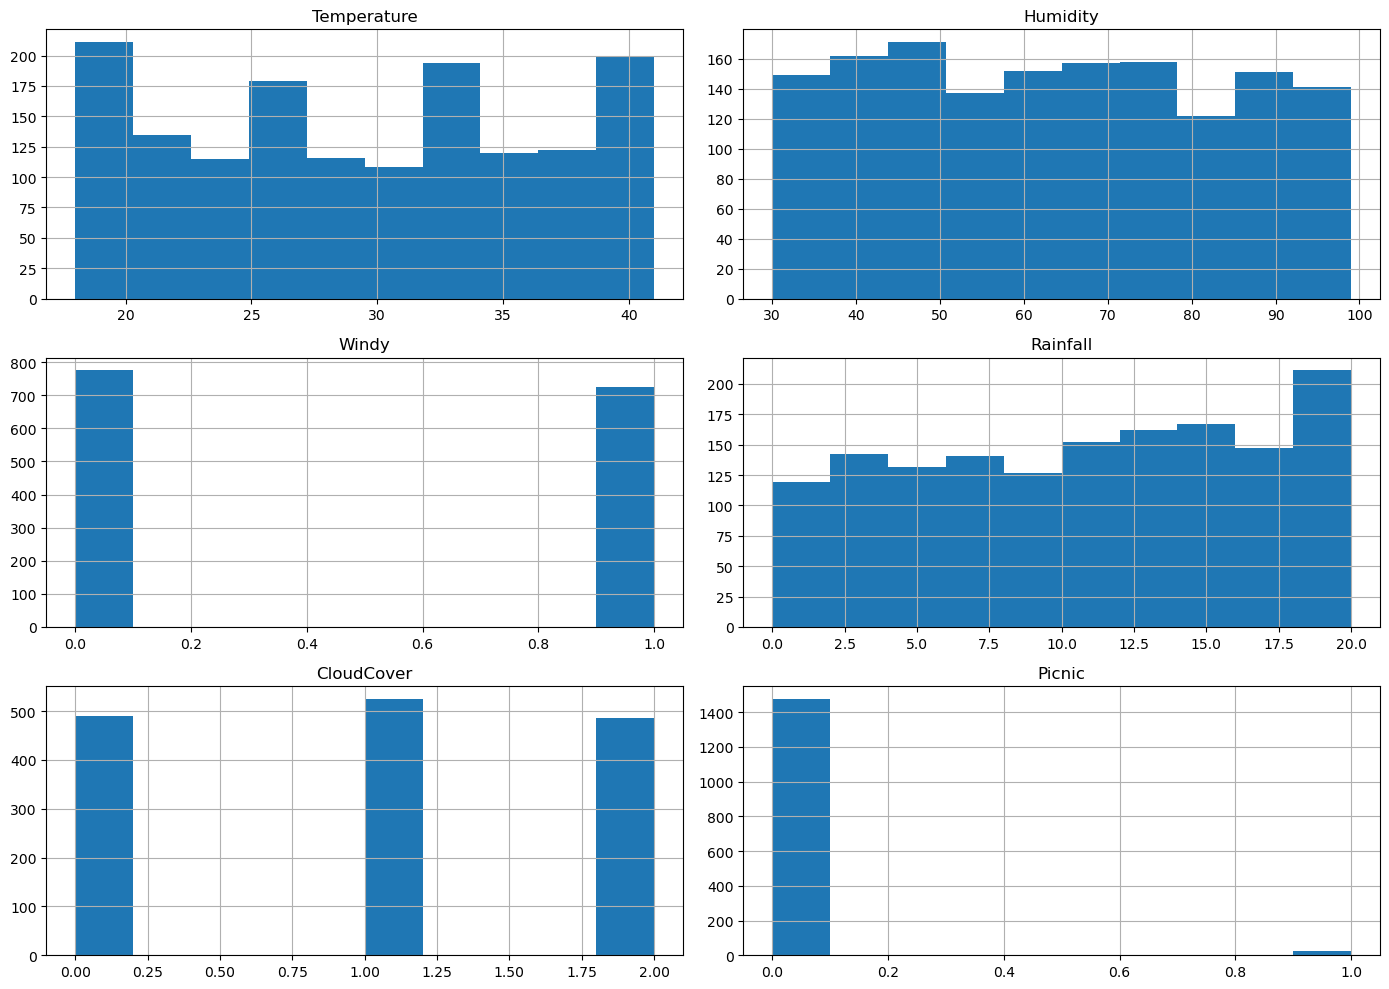

In [11]:
df.hist(

    figsize=(14,10)

)

plt.tight_layout()

plt.show()

In [12]:
corr = df.corr()

corr

,Temperature,Humidity,Windy,Rainfall,CloudCover,Picnic
Temperature,1.000000,-0.046697,0.018840,0.003049,-0.007063,-0.042262
Humidity,-0.046697,1.000000,0.037132,0.026003,-0.035963,-0.076498
Windy,0.018840,0.037132,1.000000,0.037575,0.009018,-0.123333
Rainfall,0.003049,0.026003,0.037575,1.000000,0.019173,-0.190298
CloudCover,-0.007063,-0.035963,0.009018,0.019173,1.000000,-0.157847
Picnic,-0.042262,-0.076498,-0.123333,-0.190298,-0.157847,1.000000


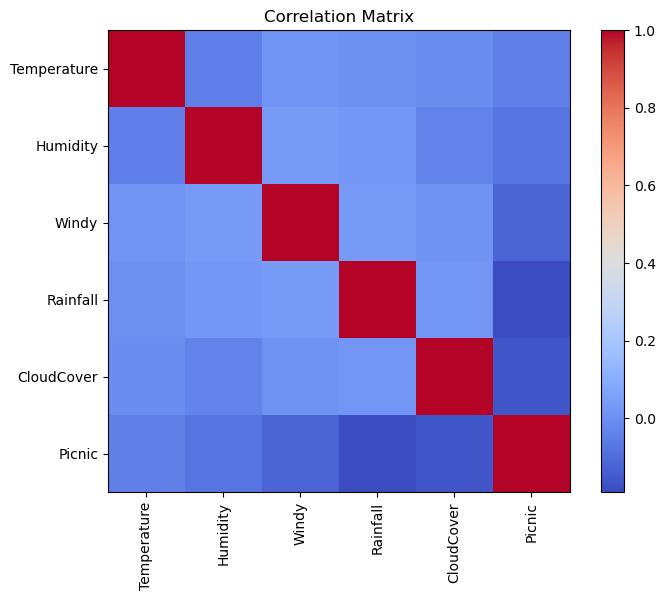

In [13]:
plt.figure(figsize=(8,6))

plt.imshow(

    corr,

    cmap="coolwarm"

)

plt.colorbar()

plt.xticks(

    range(len(corr.columns)),

    corr.columns,

    rotation=90

)

plt.yticks(

    range(len(corr.columns)),

    corr.columns

)

plt.title(

    "Correlation Matrix"

)

plt.show()

In [14]:
np.random.seed(42)

df.loc[

    np.random.choice(

        df.index,

        20

    ),

    "Humidity"

] = np.nan

df.loc[

    np.random.choice(

        df.index,

        15

    ),

    "Rainfall"

] = np.nan

In [15]:
df.isnull().sum()

Temperature     0
Humidity       20
Windy           0
Rainfall       15
CloudCover      0
Picnic          0
dtype: int64

In [16]:
df["Humidity"].fillna(

    df["Humidity"].median(),

    inplace=True

)

df["Rainfall"].fillna(

    df["Rainfall"].median(),

    inplace=True
)

In [17]:
df.isnull().sum()

Temperature    0
Humidity       0
Windy          0
Rainfall       0
CloudCover     0
Picnic         0
dtype: int64

In [18]:
duplicates = df.sample(8)

df = pd.concat(

    [

        df,

        duplicates

    ],

    ignore_index=True

)

In [19]:
df.duplicated().sum()

np.int64(10)

In [20]:
df.drop_duplicates(

    inplace=True

)

df.reset_index(

    drop=True,

    inplace=True

)

# Feature Engineering

Feature engineering helps create new features that may improve
the model's predictive performance.

New Features

1. WeatherScore
2. PleasantTemperature
3. HeavyRain
4. GoodWeather

In [21]:
# ============================================================
# Feature Engineering
# ============================================================

# Lower humidity + lower rainfall = better weather
df["WeatherScore"] = (
    100 - df["Humidity"]
) + (
    20 - df["Rainfall"]
)

# Pleasant temperature (20°C to 32°C)
df["PleasantTemperature"] = (
    (df["Temperature"] >= 20) &
    (df["Temperature"] <= 32)
).astype(int)

# Heavy Rain
df["HeavyRain"] = (
    df["Rainfall"] >= 10
).astype(int)

# Good Weather
df["GoodWeather"] = (
    (df["Humidity"] < 70) &
    (df["Rainfall"] < 4) &
    (df["Windy"] == 0)
).astype(int)

df.head()

,Temperature,Humidity,Windy,Rainfall,CloudCover,Picnic,WeatherScore,PleasantTemperature,HeavyRain,GoodWeather
0,24,77.0,0,6.0,0,0,37.0,1,0,0
1,37,88.0,0,16.0,2,0,16.0,0,1,0
2,32,68.0,0,20.0,1,0,32.0,1,1,0
3,28,47.0,1,14.0,1,0,59.0,1,1,0
4,25,88.0,0,19.0,2,0,13.0,1,1,0


In [22]:
X = df.drop("Picnic", axis=1)

y = df["Picnic"]

In [23]:
print(X.columns.tolist())

['Temperature', 'Humidity', 'Windy', 'Rainfall', 'CloudCover', 'WeatherScore', 'PleasantTemperature', 'HeavyRain', 'GoodWeather']


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [25]:
print(X_train.shape)

print(X_test.shape)

(1198, 9)
(300, 9)


# Why Feature Scaling is NOT Required?

Algorithms like

- KNN
- SVM
- K-Means

depend on distance calculations.

Decision Trees do NOT calculate distances.

Instead they compare values.

Example

Rainfall <= 4 ?

Humidity <= 70 ?

Temperature > 30 ?

Since only comparisons are made,

feature scaling has no effect.

A Decision Tree is a supervised Machine Learning algorithm.

It predicts outcomes using a sequence of IF-ELSE conditions.

Example

IF Rainfall <= 4

      IF Humidity <=70

            Picnic = Yes

      ELSE

            Picnic = No

ELSE

      Picnic = No

Root Node

↓

The first decision.

Decision Node

↓

Intermediate conditions.

Leaf Node

↓

Final prediction.

              Rainfall <=4

             /            \

          Yes             No

          |

     Humidity<=70

      /       \

    Yes        No

    |          |

 Picnic     No Picnic

# Entropy

Entropy measures impurity or disorder in a dataset.

Higher entropy

↓

More mixed classes

Lower entropy

↓

Pure classes

In [26]:
from math import log2

# Example dataset

yes = 6

no = 4

total = yes + no

p_yes = yes / total

p_no = no / total

entropy = -(

    p_yes * log2(p_yes)

    +

    p_no * log2(p_no)

)

print(entropy)

0.9709505944546686


## Information Gain
Information Gain tells us how much uncertainty
is reduced after splitting the data.

The feature with the highest Information Gain
is selected for splitting.

## Gini index ##
Gini measures impurity just like Entropy.

Lower Gini

↓

Better split

Most Decision Tree implementations in scikit-learn
use Gini by default.

In [27]:
p_yes = 0.6

p_no = 0.4

gini = 1 - (p_yes**2 + p_no**2)

print(gini)

0.48


In [28]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(

    random_state=42
)

tree.fit(

    X_train,

    y_train

)

DecisionTreeClassifier(random_state=42)

In [29]:
y_pred = tree.predict(X_test)

In [30]:
probabilities = tree.predict_proba(X_test)

probabilities[:10]

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [31]:
results = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_pred,

    "Probability_Yes": probabilities[:,1]

})

results.head(10)

,Actual,Predicted,Probability_Yes
788,0,0,0.0
1259,0,0,0.0
113,0,0,0.0
152,0,0,0.0
873,0,0,0.0
516,0,0,0.0
1095,0,0,0.0
904,0,0,0.0
944,0,0,0.0
26,0,0,0.0


# Decision Tree Visualization

One of the biggest advantages of Decision Trees is that we can
visualize the complete decision-making process.

Each node represents a condition.

Each branch represents the outcome of that condition.

Each leaf node represents the final prediction.

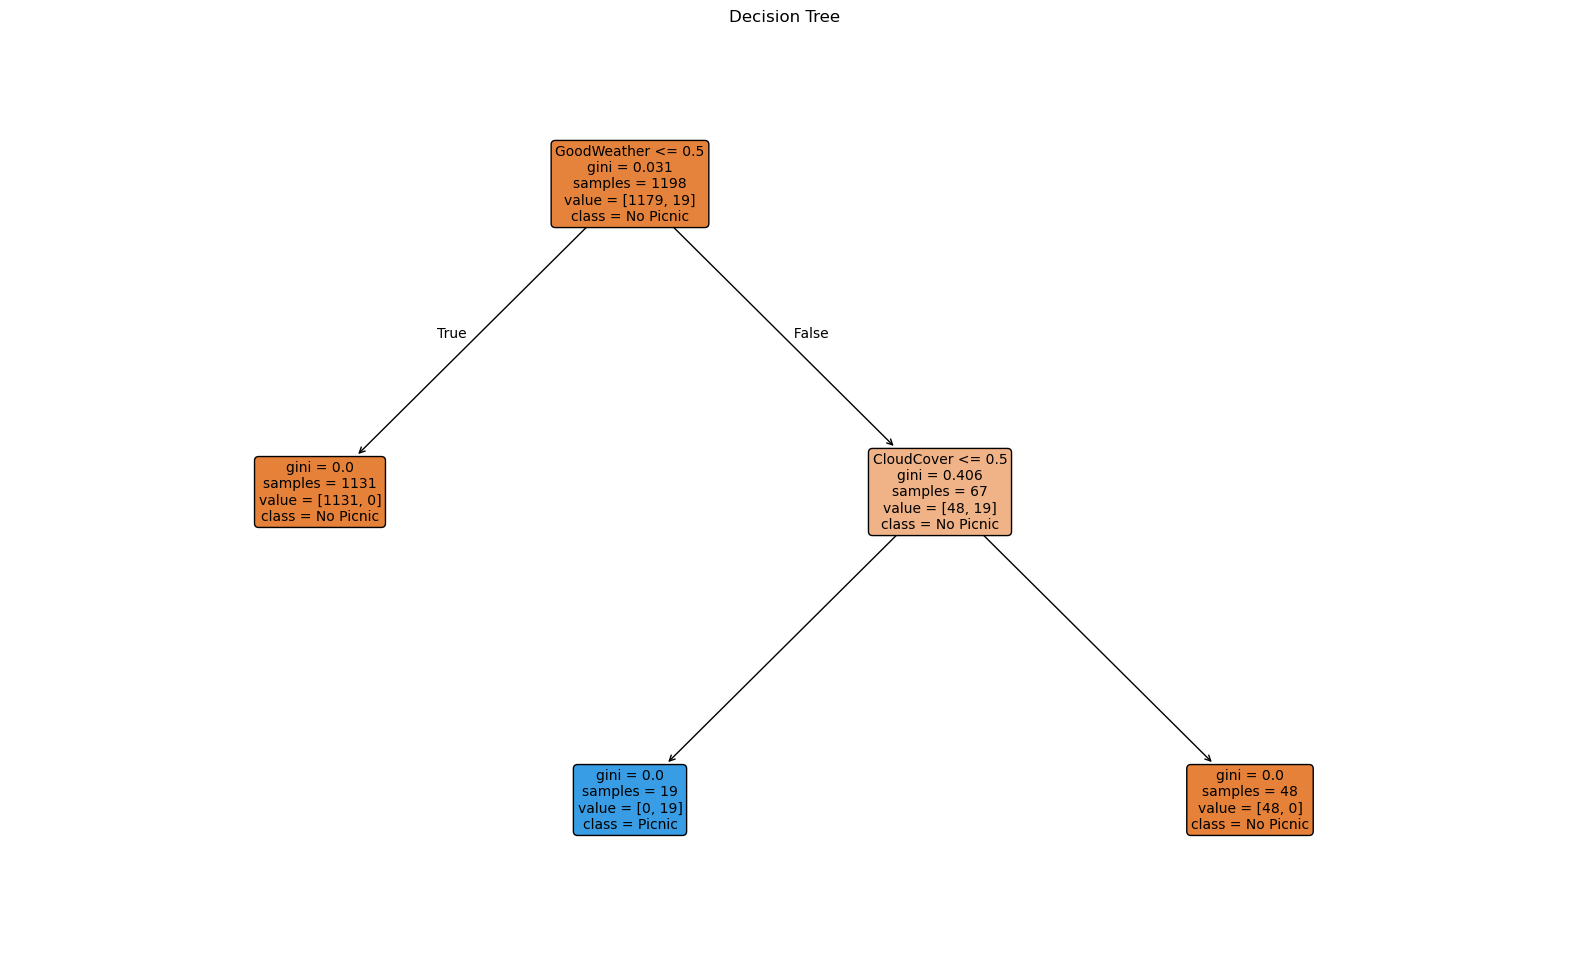

In [32]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,12))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No Picnic", "Picnic"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree")
plt.show()

In [33]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[295,   0],
       [  0,   5]])

In [34]:
tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 295
False Positive: 0
False Negative: 0
True Positive : 5


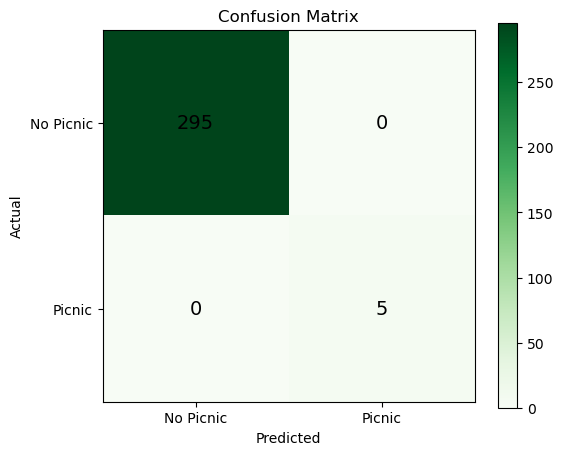

In [35]:
plt.figure(figsize=(6,5))

plt.imshow(cm, cmap="Greens")

plt.colorbar()

plt.xticks([0,1],["No Picnic","Picnic"])
plt.yticks([0,1],["No Picnic","Picnic"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                 ha="center",
                 va="center",
                 fontsize=14)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [36]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       295
           1       1.00      1.00      1.00         5

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [38]:
probabilities = tree.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, probabilities)

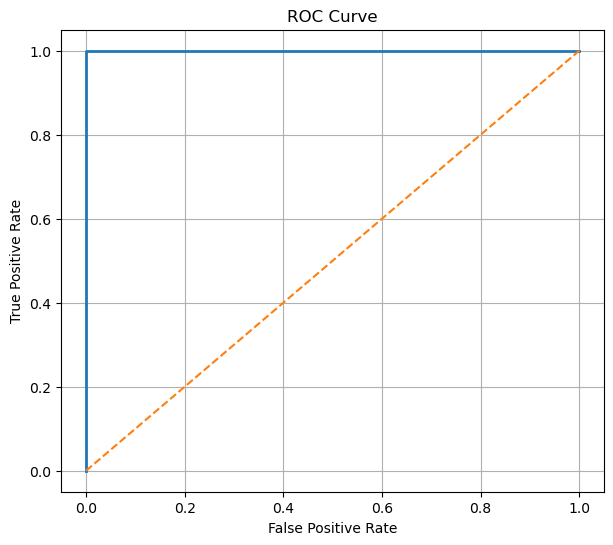

In [39]:
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.grid(True)

plt.show()

In [40]:
auc = roc_auc_score(y_test, probabilities)

print("ROC AUC Score:", auc)

ROC AUC Score: 1.0


# Feature Importance

Decision Trees automatically determine
which features are most useful for prediction.

Features with higher importance contribute
more to the decision-making process.

In [41]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":tree.feature_importances_

})

importance.sort_values(

    by="Importance",

    ascending=False,

    inplace=True
)

importance

,Feature,Importance
4,CloudCover,0.727963
8,GoodWeather,0.272037
0,Temperature,0.000000
2,Windy,0.000000
1,Humidity,0.000000
3,Rainfall,0.000000
5,WeatherScore,0.000000
6,PleasantTemperature,0.000000
7,HeavyRain,0.000000


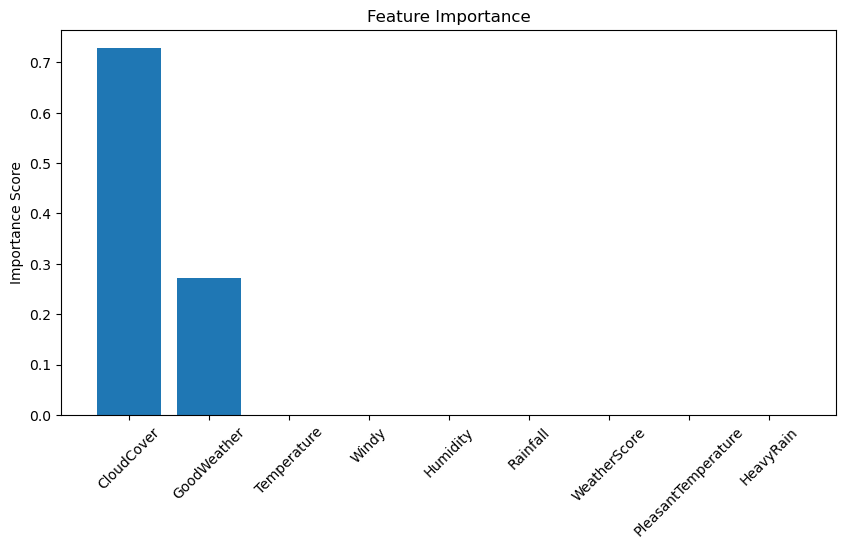

In [42]:
plt.figure(figsize=(10,5))

plt.bar(

    importance["Feature"],

    importance["Importance"]

)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.ylabel("Importance Score")

plt.show()

# Overfitting

Decision Trees can grow until every leaf
contains very few samples.

This perfectly fits the training data but
reduces performance on unseen data.

We control overfitting using:

- max_depth
- min_samples_split
- min_samples_leaf
- max_leaf_nodes

In [43]:
deep_tree = DecisionTreeClassifier(

    max_depth=3,

    random_state=42

)

deep_tree.fit(

    X_train,

    y_train
)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [44]:
deep_prediction = deep_tree.predict(X_test)

print(

    accuracy_score(

        y_test,

        deep_prediction

    )

)

1.0


In [45]:
depth = []

accuracy_list = []

for d in range(1,11):

    model = DecisionTreeClassifier(

        max_depth=d,

        random_state=42

    )

    model.fit(

        X_train,

        y_train

    )

    pred = model.predict(X_test)

    depth.append(d)

    accuracy_list.append(

        accuracy_score(

            y_test,

            pred

        )

    )

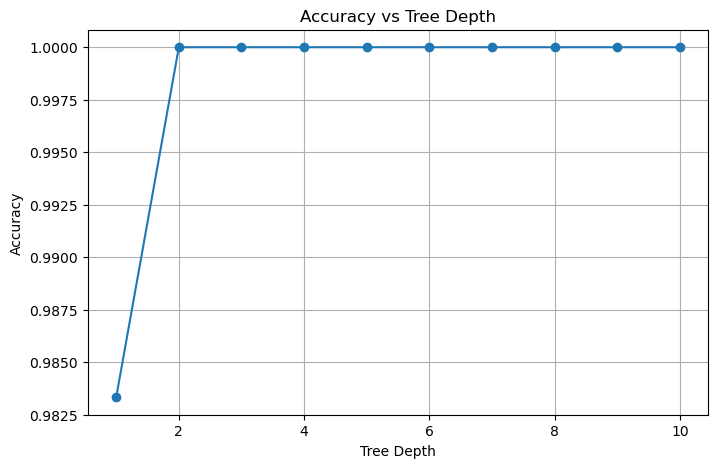

In [47]:
plt.figure(figsize=(8,5))

plt.plot(

    depth,

    accuracy_list,

    marker="o"

)

plt.xlabel("Tree Depth")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Tree Depth")

plt.grid(True)

plt.show()

In [48]:
from sklearn.model_selection import GridSearchCV

parameters = {

    "criterion":["gini","entropy"],

    "max_depth":[

        3,5,7,9,None

    ],

    "min_samples_split":[

        2,5,10

    ],

    "min_samples_leaf":[

        1,2,5

    ]

}

grid = GridSearchCV(

    DecisionTreeClassifier(

        random_state=42

    ),

    parameters,

    cv=5,

    scoring="accuracy"

)

grid.fit(

    X_train,

    y_train
)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 9, None],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [49]:
print("Best Parameters")

print(grid.best_params_)

print()

print("Best Accuracy")

print(grid.best_score_)

Best Parameters
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Accuracy
1.0


In [50]:
best_tree = grid.best_estimator_

final_prediction = best_tree.predict(X_test)

print(

    classification_report(

        y_test,

        final_prediction

    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       295
           1       1.00      1.00      1.00         5

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [51]:
import joblib

joblib.dump(

    best_tree,

    "WeatherDecisionTree.pkl"

)

print("Model Saved Successfully!")

Model Saved Successfully!


In [53]:
loaded_model = joblib.load(

    "WeatherDecisionTree.pkl"
)

In [54]:
new_weather = pd.DataFrame({

    "Temperature":[28],

    "Humidity":[60],

    "Windy":[0],

    "Rainfall":[2],

    "CloudCover":[0],

    "WeatherScore":[58],

    "PleasantTemperature":[1],

    "HeavyRain":[0],

    "GoodWeather":[1]

})

prediction = loaded_model.predict(new_weather)

probability = loaded_model.predict_proba(new_weather)

print("="*60)

print("🌤 WEATHER-BASED PICNIC PREDICTION")

print("="*60)

print(f"Probability of No Picnic : {probability[0][0]*100:.2f}%")

print(f"Probability of Picnic    : {probability[0][1]*100:.2f}%")

print()

if prediction[0] == 1:
    print("✅ Picnic Can Be Conducted")
else:
    print("❌ Picnic Should Be Cancelled")

print("="*60)

🌤 WEATHER-BASED PICNIC PREDICTION
Probability of No Picnic : 0.00%
Probability of Picnic    : 100.00%

✅ Picnic Can Be Conducted
